In [85]:
import numpy as np

import rasterio
from skimage.feature import canny
from scipy.ndimage import binary_closing, binary_opening, generate_binary_structure

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [4]:
def normalize(array):
    array_min, array_max = np.nanmin(array), np.nanmax(array)
    return ((array - array_min)/(array_max - array_min))

In [5]:
def get_ndwi(green, nir):
    np.seterr(divide='ignore', invalid='ignore')
    ndwi = (green - nir) / (green + nir)
    return ndwi

In [6]:
years = [2020, 2021, 2023, 2024, 2025, 2026]
ndwi = list()

with rasterio.open(f'./images/{years[0]}/clipped_img_{years[0]}.tiff') as src:
    pattern_shape = (src.height, src.width)

for year in years:

    with rasterio.open(f'./images/{year}/clipped_img_{year}.tiff') as raster:
        nir = raster.read(4, out_shape = pattern_shape).astype(np.float32)
        green = raster.read(2, out_shape = pattern_shape).astype(np.float32)

        nir_n = normalize(nir)
        green_n = normalize(green)
        ndwi.append(get_ndwi(green_n, nir_n))
    
    

In [52]:
def normalize_color(pasmo):
    p2, p98 = np.percentile(pasmo[pasmo > 0], (2, 98))
    pasmo_norm = np.clip(pasmo, p2, p98)
    return ((pasmo_norm - p2) / (p98 - p2) * 255).astype(np.uint8)

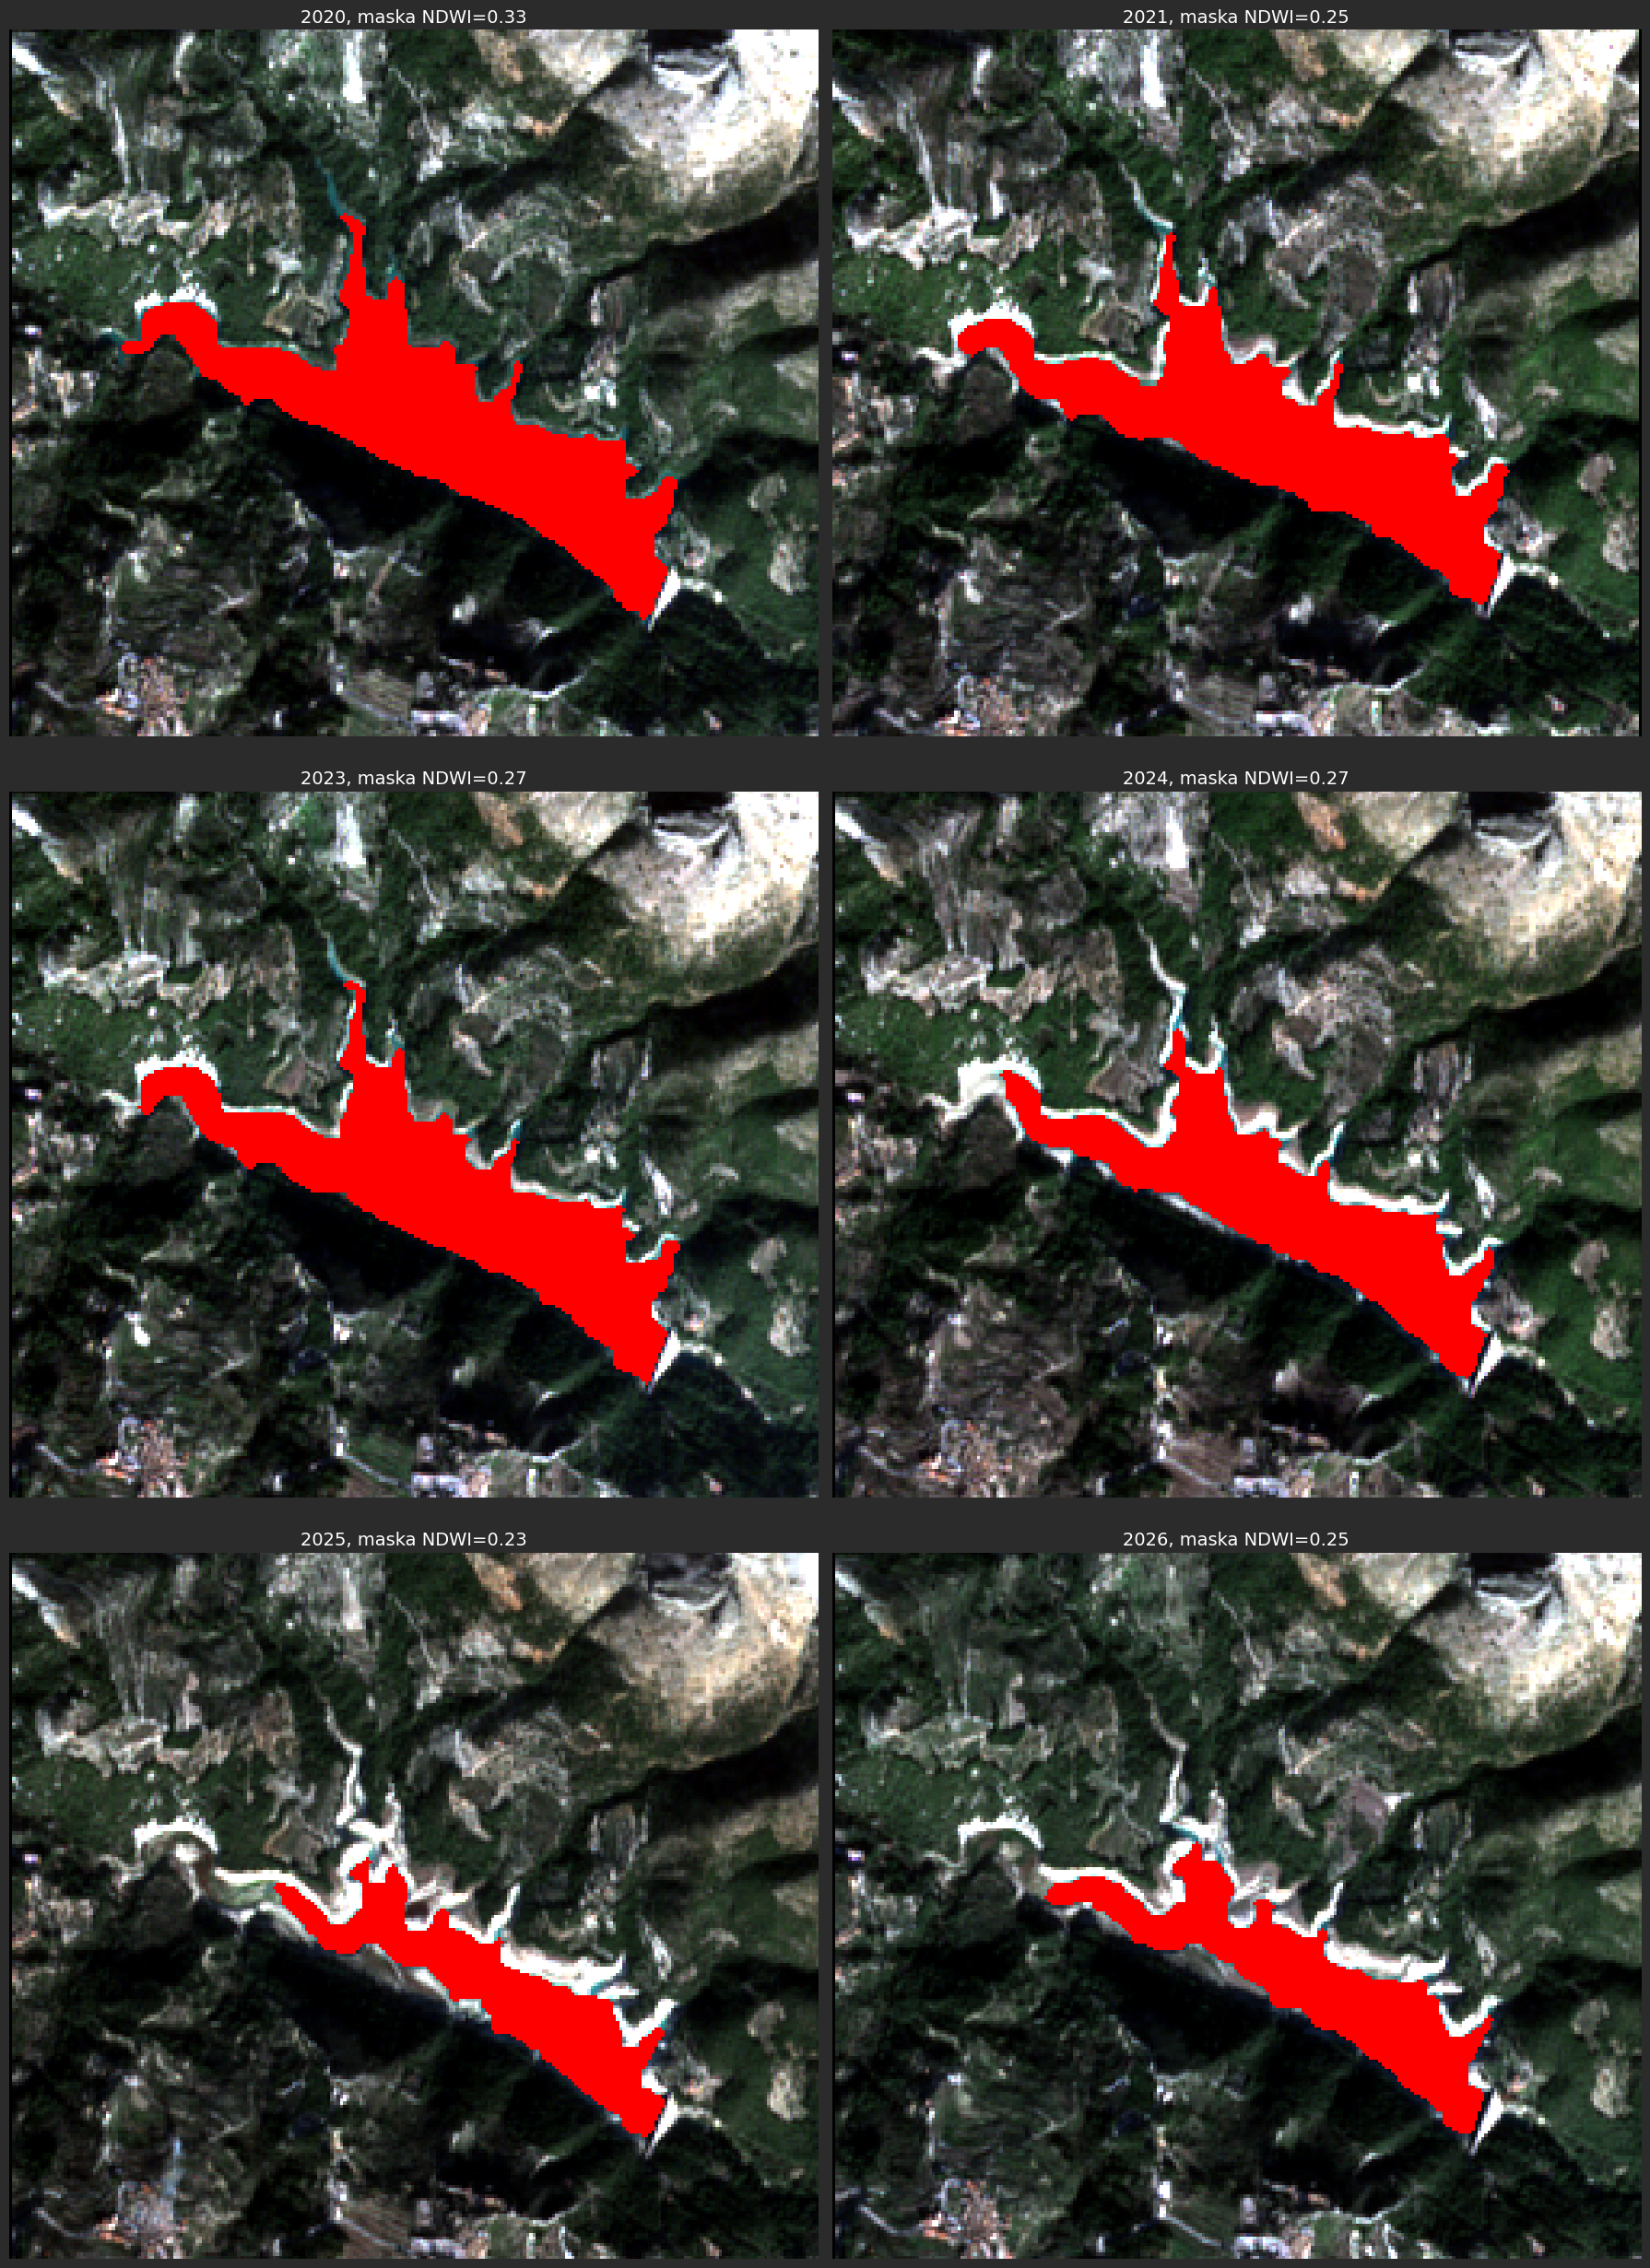

In [116]:
masks = list()
ndwi_threshold = [0.33, 0.25, 0.27, 0.27, 0.23, 0.25]
cross_structure = np.array([[0, 1, 0],
                            [1, 1, 1],
                            [0, 1, 0]], dtype=np.uint8)
for ndwi_id, year in enumerate(years):
    mask = (ndwi[ndwi_id] > ndwi_threshold[ndwi_id]).astype(np.uint8)
    mask_open = binary_opening(mask, structure=cross_structure)
    mask_close = binary_closing(mask_open, structure=np.ones((5, 5))).astype(np.float32)
    masks.append(mask_close)

masks_show = list()
for mask_id, mask in enumerate(masks):
    with rasterio.open(f'./images/{years[mask_id]}/clipped_img_{years[mask_id]}.tiff') as src:
        red = src.read(3, out_shape=pattern_shape).astype(np.float32)
        green = src.read(2, out_shape= pattern_shape).astype(np.float32)
        blue = src.read(1, out_shape= pattern_shape).astype(np.float32)
    red = normalize_color(red)
    green = normalize_color(green)
    blue = normalize_color(blue)
    img_change = np.dstack((red, green, blue))
    img_change[mask == 1] = [255, 0, 0]
    masks_show.append(img_change)


fig, axes = plt.subplots(3, 2, figsize=(18, 25), facecolor='#2b2b2b')
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(masks_show[i], cmap='gray')
    
    axes[i].set_title(f"{years[i]}, maska NDWI={ndwi_threshold[i]}", color='white', fontsize=14)
    axes[i].axis('off')
    
plt.tight_layout()

plt.show()


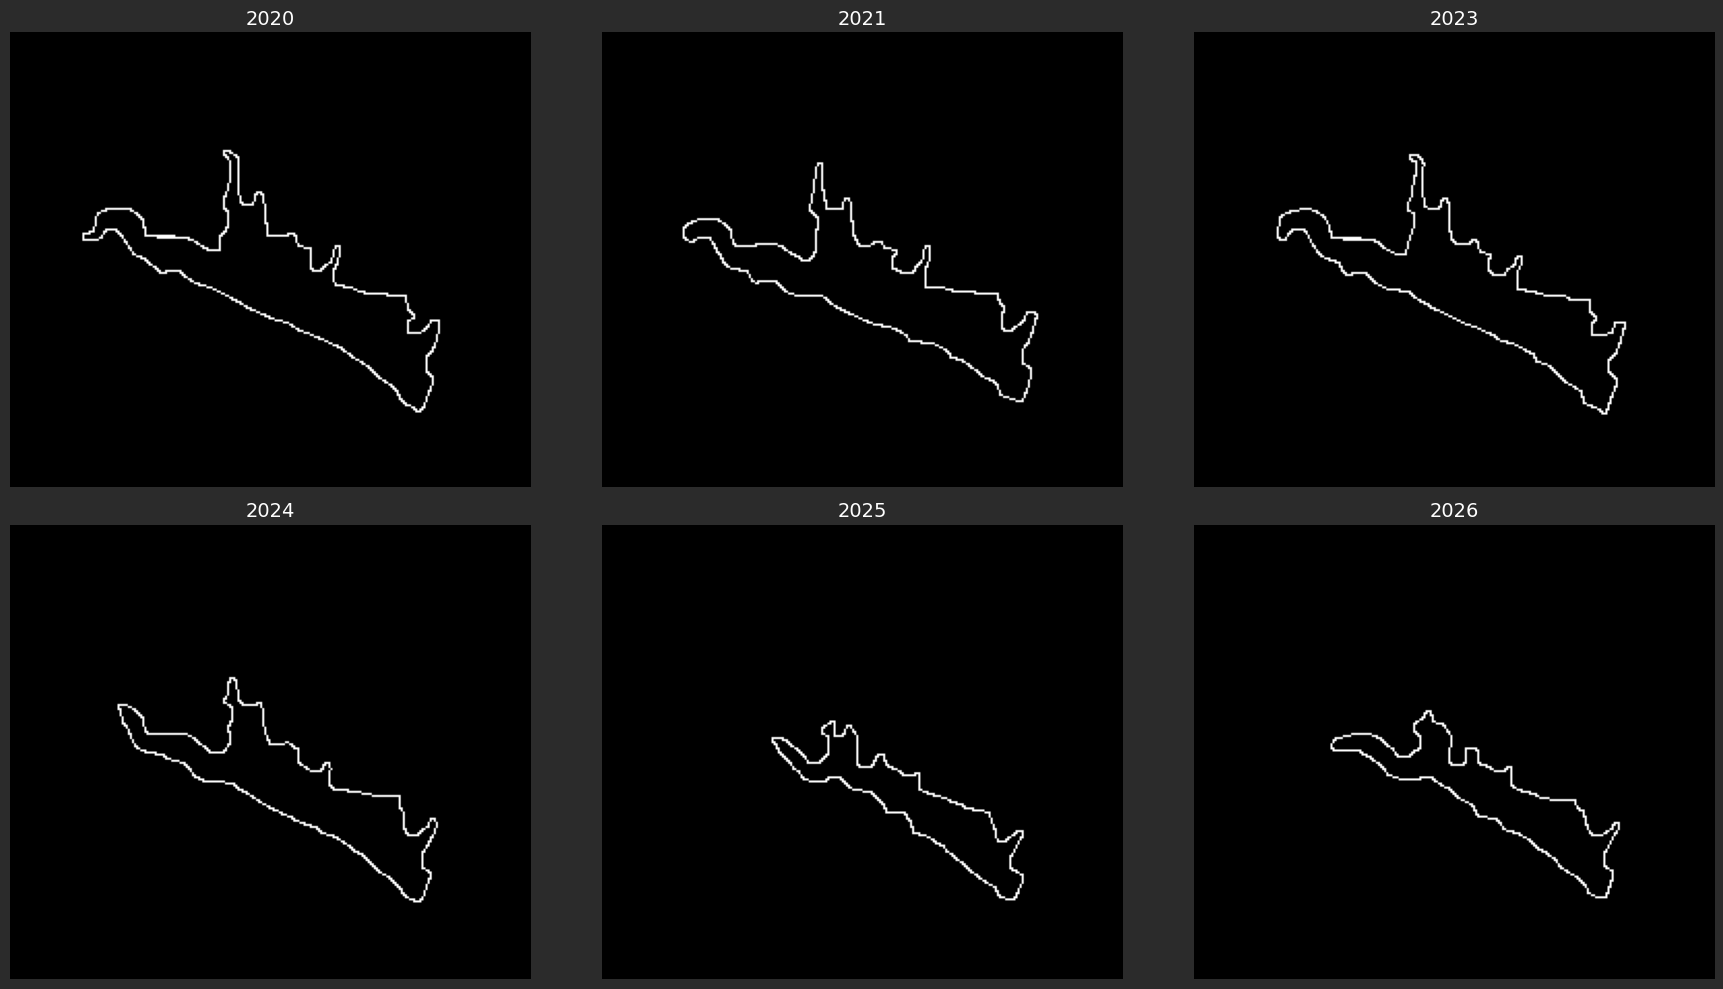

In [117]:
edges = list()
for img_id, year in enumerate(years):
    edge = canny(masks[img_id], sigma=1).astype(np.uint8)
    edges.append(edge)


fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#2b2b2b')
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(edges[i], cmap='gray')
    axes[i].set_title(years[i], color='white', fontsize=14)
    axes[i].axis('off')
    
plt.tight_layout()

plt.show()

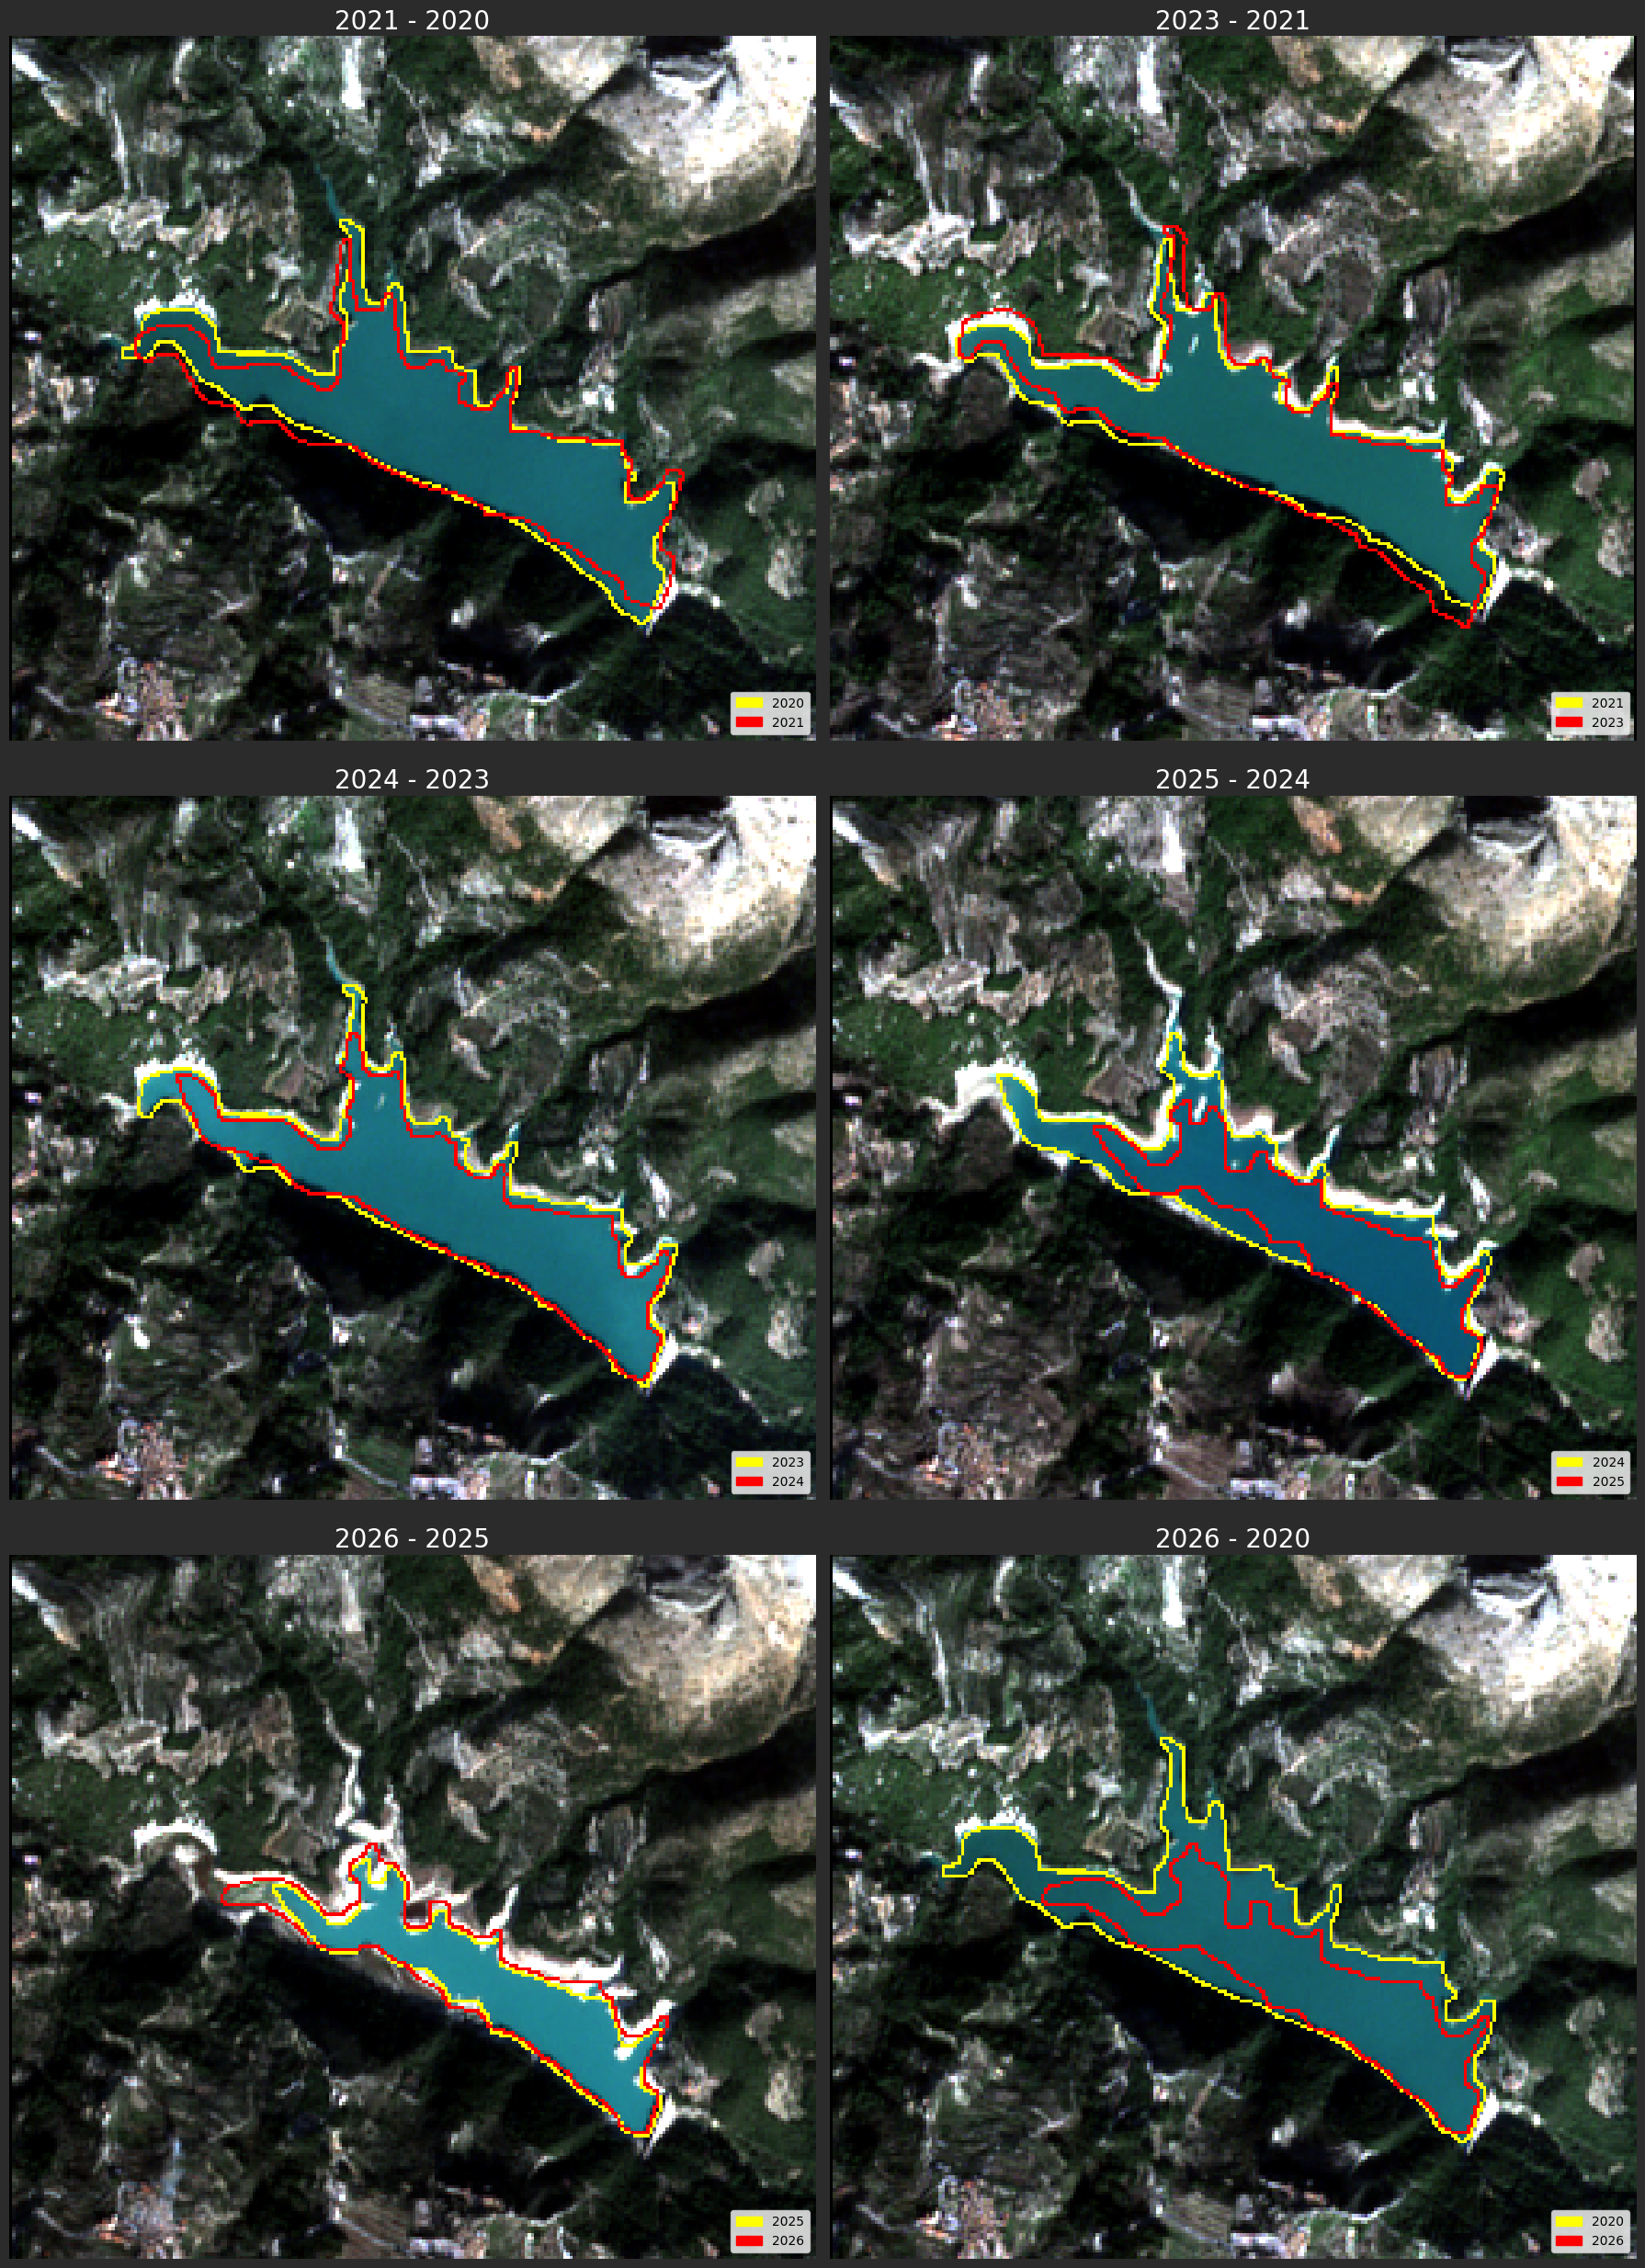

In [118]:
images_change = list()
pairs = list((i, i+1) for i in range(len(years)-1))


pairs.append((0, len(years)-1))
for old_id, new_id in pairs:
    with rasterio.open(f'./images/{years[old_id]}/clipped_img_{years[old_id]}.tiff') as src:
        red = src.read(3, out_shape=pattern_shape).astype(np.float32)
        green = src.read(2, out_shape= pattern_shape).astype(np.float32)
        blue = src.read(1, out_shape= pattern_shape).astype(np.float32)
    red = normalize_color(red)
    green = normalize_color(green)
    blue = normalize_color(blue)
    img_change = np.dstack((red, green, blue))
    img_change[edges[old_id] == 1] = [255, 255, 0]
    img_change[edges[new_id] == 1] = [255, 0, 0]
    images_change.append(img_change)


fig, axes = plt.subplots(3, 2,  figsize=(18, 25), facecolor='#2b2b2b')
axes = axes.flatten()
for img_id, img in enumerate(images_change):
    axes[img_id].imshow(img, cmap='gray')
    old, new = pairs[img_id]
    axes[img_id].set_title(f"{years[new]} - {years[old]}", color='white', fontsize=20)
    axes[img_id].axis('off')

    legend_item_1 = mpatches.Patch(color='yellow', label=str(years[old]))
    legend_item_2 = mpatches.Patch(color='red', label=str(years[new]))
    
    axes[img_id].legend(
        handles=[legend_item_1, legend_item_2], 
        loc='lower right',    
        fontsize=10
    )
    
plt.tight_layout()

plt.show()


